---
## **Curso**: Pós-graduação em Ciência de Dados e Inteligência Artificial
## **Unidade Curricular**: Machine Learning
## **Professor**: Matheus Vanzan
## **Data**: 25/09/2025 (Aula Síncrona 6)
---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, validation_curve, learning_curve, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier

# 📊 Dataset - Breast Cancer

- **Fonte:** disponível no `sklearn.datasets`  
- **Objetivo:** prever se o tumor é **maligno** ou **benigno** a partir de medidas das células do tecido mamário  
- **Classes:**
  - `malignant` (maligno)  
  - `benign` (benigno)  
- **Número de amostras:** 569  
- **Número de features:** 30 (todas numéricas, derivadas de imagens digitalizadas de tecido)  
- **Exemplos de features:**  
  - `mean radius` (raio médio das células)  
  - `mean texture` (textura média)  
  - `worst concave points` (pontos côncavos mais irregulares)  
  - `mean area`, `mean smoothness`, etc.  


Esse dataset é bastante usado em tutoriais de classificação porque:  
- Tem **classes balanceadas** (~37% malignos, ~63% benignos)  
- Features já estão **numéricas**, sem necessidade de codificação  
- Permite observar bem como as árvores e ensembles lidam com variáveis correlacionadas


## ➡️ Carregamento e Análise dos Dados

In [ ]:
data = load_breast_cancer()

In [ ]:
data.keys()

In [ ]:
data.feature_names

In [ ]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)

In [ ]:
df['target'] = data.target_names[data.target]

In [ ]:
df.head()

> **🎯 Momento de Praticar**

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.nunique()

In [ ]:
df.isnull().sum()

In [ ]:
df[df.duplicated(keep=False)]

In [ ]:
df.describe()

In [ ]:
df['target'].value_counts()

In [ ]:
df['target'].value_counts().plot(kind='bar')

In [ ]:
categorical = df.select_dtypes(include='object').columns.tolist()

In [ ]:
numerical = df.select_dtypes(include='number').columns.tolist()

In [ ]:
bins = int(np.sqrt(len(df)))

In [ ]:
def plot_histograms(df, column, category_col, bins):
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, hue=category_col, kde=True, bins=bins, palette='tab10', element='step')
    plt.title(f'Histograma de {column} por {category_col}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.show()

In [ ]:
for column in df.columns:
  plot_histograms(df, column, 'target', bins)

In [ ]:
def plot_boxplots_category(df, column, category_col):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=category_col, y=column, hue=category_col, palette='tab10')
    plt.title(f'Boxplot de {column} por {category_col}')
    plt.xlabel(category_col)
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [ ]:
for column in numerical:
  plot_boxplots_category(df, column, 'target')

## ➡️ Correlação de dados

In [ ]:
def plot_correlation_matrix(df):
    corr_df = df[df.select_dtypes(include=['float']).columns]
    plt.figure(figsize=(14, 12))
    correlation_matrix = corr_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlação')
    plt.show()

In [ ]:
plot_correlation_matrix(df)

In [ ]:
# sns.pairplot(df, hue='target')
# plt.show()

In [ ]:
def remove_outliers_iqr(df, column, category_col=None):
    if category_col:
        filtered_df = pd.DataFrame()
        for category in df[category_col].unique():
            subset = df[df[category_col] == category]
            Q1 = subset[column].quantile(0.25)
            Q3 = subset[column].quantile(0.75)
            IQR = Q3 - Q1
            mask = (subset[column] >= Q1 - 1.5 * IQR) & (subset[column] <= Q3 + 1.5 * IQR)
            filtered_df = pd.concat([filtered_df, subset[mask]])
        return filtered_df
    else:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)
        return df[mask]

In [ ]:
for column in numerical:
  df = remove_outliers_iqr(df, column, 'target')

# **📌 Decision Tree**

A **Árvore de Decisão (Decision Tree)** é um algoritmo de aprendizado supervisionado que pertence à classe dos **métodos baseados em modelo**. Isso significa que ele **constrói um modelo durante o treinamento**, aprendendo regras de decisão a partir dos dados para fazer previsões.

Durante o treinamento, a árvore é construída de forma **recursiva**, dividindo o conjunto de dados em **subconjuntos cada vez mais homogêneos** com base em atributos que melhor separam as classes (na classificação) ou reduzem o erro (na regressão). Essa divisão é feita por meio de métricas como **Gini, entropia** ou **erro quadrático médio**, dependendo do tipo de tarefa.

Na **classificação**, a árvore atribui à nova amostra a classe da folha em que ela termina. Na **regressão**, a predição é feita com base na média dos valores das amostras da folha correspondente. O modelo resultante é fácil de interpretar, já que as decisões são estruturadas em forma de **"se-então"**, como um fluxograma.

As Árvores de Decisão são versáteis e funcionam bem em problemas com **relações não lineares** entre atributos. No entanto, podem ser **sensíveis a variações nos dados** e propensas ao **overfitting**, especialmente se não forem podadas ou regularizadas. Ainda assim, sua **transparência e simplicidade** as tornam populares em aplicações práticas e como base para métodos mais robustos, como o Random Forest.

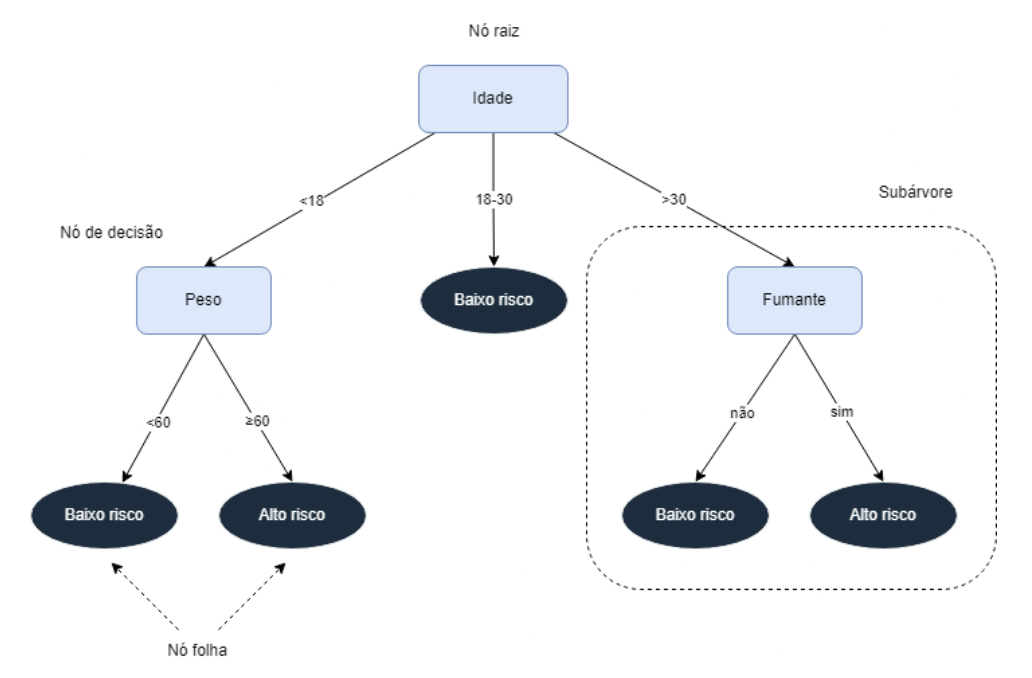

## ➡️ Treinamento

In [ ]:
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

> **🎯 Momento de Praticar**

⚠️ Aqui o escalonamento (StandardScaler) é desnecessário.

Árvores não usam distâncias → o valor absoluto das features não importa, ele é apenas utilizado como um fator de decisão para os nós.

In [ ]:
# pre = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical),
#     ]
# )

In [ ]:
pipe_dt = Pipeline(steps=[
    # ('pre', pre),
    ('dt', DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=10))
])

In [ ]:
pipe_dt.fit(X_train, y_train)

In [ ]:
y_pred = pipe_dt.predict(X_test)

## ➡️ Plot da Árvore de Decisão

Cada nó da árvore traz informações importantes:

- **Pergunta (feature e limiar):**  
  Ex.: `worst concave points <= 0.131` → Divide os dados em **esquerda (True)** e **direita (False)**

- **Impureza (gini):**  
  - Mede o quão misturadas estão as classes no nó  
  - `gini = 0` → nó puro (só uma classe)  
  - `gini ≈ 0.5` → mistura máxima (classes equilibradas)

- **Samples:** Número de amostras que chegaram nesse nó

- **Value:** Distribuição de amostras por classe  
  Ex.: `[148, 105]` → 148 benignos, 105 malignos

- **Class:** Classe prevista no nó (a mais frequente)

> Cores dos nós:

- **Laranja** → Nó predominante da classe **benign**  
- **Azul** → Nó predominante da classe **malignant**  
- **Mais forte = maior pureza** (mais concentrado em uma única classe)  
- **Mais claro = maior mistura** de classes


> Interpretação:

A cada pergunta, seguimos o **ramo esquerdo (True)** ou o **ramo direito (False)**.  
No final (folha), a árvore dá a **classe prevista** para aquela combinação de respostas.


In [ ]:
dt = pipe_dt.named_steps['dt']

In [ ]:
plt.figure(figsize=(24, 16))

plot_tree(dt, filled=True, feature_names=X.columns, class_names=dt.classes_)
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

plot_tree(dt, filled=True, feature_names=X.columns, class_names=dt.classes_, max_depth=2)
plt.show()

In [ ]:
pd.DataFrame(y_train).value_counts()

In [ ]:
df[df['worst concave points'] > 0.131]['target'].value_counts()

## ➡️ Relevância das features

In [ ]:
dt = pipe_dt.named_steps['dt']

In [ ]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

# Mostra top 10
print(importances.head(10))

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Top 10 features - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

## ➡️ Avaliação

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

In [ ]:
cv_scores = cross_val_score(pipe_dt, X, y, cv=10, scoring='accuracy')

print(f"\nAcurácias da Validação Cruzada: {cv_scores}")
print(f"Acurácia Média CV: {np.mean(cv_scores):.4f}")
print(f"Desvio Padrão CV: {np.std(cv_scores):.4f}")

# **📌 Random Forest**

O **Random Forest** é um algoritmo de aprendizado supervisionado que pertence à classe dos **métodos baseados em conjunto (ensemble)**. Isso significa que ele **combina vários modelos simples** – no caso, múltiplas Árvores de Decisão – para formar um modelo mais robusto e preciso.

Durante o treinamento, o Random Forest constrói diversas árvores de decisão de forma **independente**, cada uma treinada com uma **amostra aleatória dos dados**, em um processo chamado **bootstrap**. Além disso, em cada divisão dentro de uma árvore, **um subconjunto aleatório de atributos é considerado**, o que introduz diversidade entre as árvores e reduz a correlação entre elas.

Na **classificação**, cada árvore vota em uma classe, e o Random Forest escolhe a classe com **maior número de votos (maioria simples)**. Na **regressão**, a predição final é a **média das saídas** de todas as árvores. Esse processo de agregação contribui para **reduzir o overfitting**, um problema comum nas árvores individuais.

O Random Forest é poderoso em tarefas com **muitos atributos e dados ruidosos**, pois sua abordagem em conjunto ajuda a capturar **relações complexas** sem sacrificar a **generalização**. Embora perca em **interpretação** em relação a uma árvore única, compensa com **melhor desempenho e maior robustez**, sendo amplamente utilizado em aplicações do mundo real.

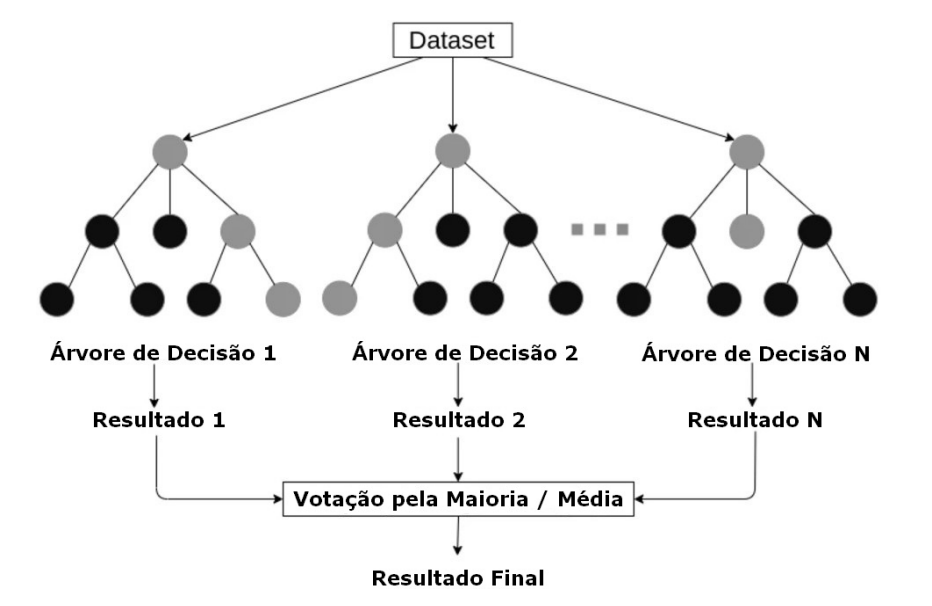

## ➡️ Treinamento

In [ ]:
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

> **🎯 Momento de Praticar**

In [ ]:
pipe_rf = Pipeline(steps=[
    # ('pre', pre),
    ('rf', RandomForestClassifier(n_estimators=10, criterion='gini', random_state=42))
])

In [ ]:
pipe_rf.fit(X_train, y_train)

In [ ]:
y_pred = pipe_rf.predict(X_test)

## ➡️ Relevância das features

In [ ]:
rf = pipe_rf.named_steps['rf']

In [ ]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Mostra top 10
print(importances.head(10))

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Top 10 features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## ➡️ Avaliação

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

In [ ]:
cv_scores = cross_val_score(pipe_rf, X, y, cv=10, scoring='accuracy')

print(f"\nAcurácias da Validação Cruzada: {cv_scores}")
print(f"Acurácia Média CV: {np.mean(cv_scores):.4f}")
print(f"Desvio Padrão CV: {np.std(cv_scores):.4f}")

# **📌 XGBoost**

O **XGBoost (Extreme Gradient Boosting)** é um algoritmo de aprendizado supervisionado que pertence à classe dos **métodos de ensemble baseados em boosting**. Diferente do Random Forest, que constrói árvores em paralelo, o XGBoost constrói **árvores de forma sequencial**, onde **cada nova árvore corrige os erros** cometidos pelas anteriores.

Durante o treinamento, o modelo é construído iterativamente: a cada etapa, o XGBoost ajusta uma nova árvore aos **resíduos (erros)** do modelo atual. Esse processo é guiado pelo **gradiente do erro da função de perda**, daí o nome *gradient boosting*. As predições são atualizadas a cada nova árvore, somando suas contribuições ao modelo final.

O XGBoost inclui diversas **técnicas de regularização**, como **penalizações L1 e L2**, que ajudam a evitar o overfitting, além de utilizar **poda sob demanda**, **paralelização eficiente**, **tratamento interno de valores ausentes**, e **otimizações de hardware** que o tornam extremamente rápido e eficaz, mesmo em conjuntos de dados grandes e complexos.

Na **classificação**, o XGBoost retorna a classe com maior pontuação agregada, enquanto na **regressão**, retorna a soma ponderada das previsões das árvores. O modelo final tende a ser mais **preciso**, embora menos interpretável do que modelos como Árvore de Decisão ou mesmo o Random Forest.

Graças à sua **eficiência, flexibilidade e desempenho superior**, o XGBoost é uma das ferramentas mais populares em competições de ciência de dados e aplicações industriais exigentes.

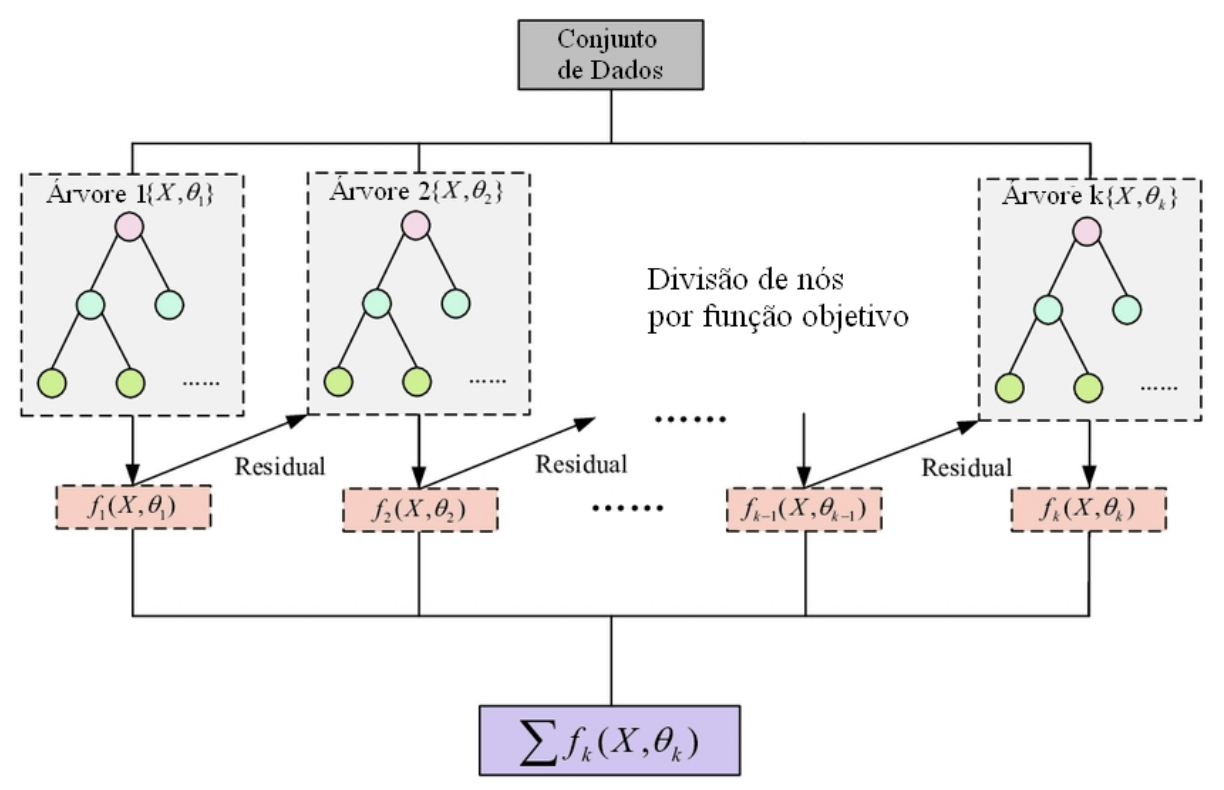

## ➡️ Treinamento

In [ ]:
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

In [ ]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y)

> **🎯 Momento de Praticar**

In [ ]:
pipe_xgb = Pipeline(steps=[
    # ('pre', pre),
    ('xgb', XGBClassifier(random_state=42))
])

In [ ]:
pipe_xgb.fit(X_train, y_train)

In [ ]:
y_pred = pipe_xgb.predict(X_test)

## ➡️ Relevância das features

In [ ]:
xgb = pipe_xgb.named_steps['xgb']

In [ ]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Mostra top 10
print(importances.head(10))

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Top 10 features - XGBoost")
plt.gca().invert_yaxis()
plt.show()

## ➡️ Avaliação

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

In [ ]:
cv_scores = cross_val_score(pipe_xgb, X, y_enc, cv=10, scoring='accuracy')

print(f"\nAcurácias da Validação Cruzada: {cv_scores}")
print(f"Acurácia Média CV: {np.mean(cv_scores):.4f}")
print(f"Desvio Padrão CV: {np.std(cv_scores):.4f}")

# 🔎 Comparativo



- Árvores de decisão são fáceis de interpretar, mas podem sofrer com overfitting.  
- Random Forest usa **bagging** para reduzir variância e aumentar a robustez.  
- XGBoost é uma evolução com **boosting**, geralmente alcançando melhor performance.  
- Feature importances ajudam a entender quais variáveis foram mais relevantes.  
- Overfitting pode ser controlado com parâmetros como `max_depth`, `min_samples_leaf`.  


## ➡️ Modelos treinados

In [ ]:
models = [
    ('Decision Tree', pipe_dt),
    ('Random Forest', pipe_rf),
    ('XGBoost', pipe_xgb)
]
y_enc = LabelEncoder().fit_transform(y)


results = []
for name, pipe in models:
    cv_acc = cross_val_score(pipe, X, y_enc, cv=10, scoring='accuracy')
    cv_f1 = cross_val_score(pipe, X, y_enc, cv=10, scoring='f1_macro')

    results.append({
        'Model': name,
        'Accuracy': np.mean(cv_acc),
        'F1_macro': np.mean(cv_f1)
    })

# Converter para DataFrame
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(df_results)

In [ ]:
# Plot comparativo
plt.figure(figsize=(8,5))
x = np.arange(len(df_results))
width = 0.35

plt.bar(x - width/2, df_results['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, df_results['F1_macro'], width, label='F1_macro')

plt.xticks(x, df_results['Model'])
plt.ylabel('Score')
plt.title('Comparação de Modelos (CV=10)')
plt.legend()
plt.ylim(0.9,1)
plt.show()

## ➡️ Busca de parâmetros

In [ ]:
pipe = Pipeline([
    ("clf", DecisionTreeClassifier())   # placeholder
])

param_grid = [
    {
        "clf": [DecisionTreeClassifier(random_state=42)],
        "clf__max_depth": [10, 20, 30]
    },
    {
        "clf": [RandomForestClassifier(random_state=42)],
        "clf__n_estimators": [10, 20, 30, 40, 50],
        "clf__max_depth": [10, 20, 30]
    },
    {
        "clf": [XGBClassifier(eval_metric="logloss", random_state=42)],
        "clf__n_estimators":[10, 20, 30, 40, 50],
        "clf__max_depth": [10, 20, 30]
    }
]

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", error_score='raise')
grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_estimator_)
print("Melhores parâmetros:", grid.best_params_)
print("Melhor score:", grid.best_score_)


# 💻 Exercício - Aprovação de Crédito

Utilize o dataset **Credit Approval** (UCI / OpenML, nome: `credit-g`).

1. **Carregue o dataset** via `fetch_openml("credit-g")`.  
   - O target indica se o crédito foi **aprovado** ou **recusado**.  
   - As features incluem atributos numéricos e categóricos (idade, saldo, histórico, etc.).  

2. **Pré-processamento:**  
   - Aplique `OneHotEncoder` para transformar variáveis categóricas.  
   - Separe em treino e teste (70/30).  

3. **Árvore de Decisão:**  
   - Treine um `DecisionTreeClassifier`.  
   - Avalie acurácia, matriz de confusão e `classification_report`.  
   - Teste diferentes valores de `max_depth` e comente o impacto no overfitting.  

4. **Random Forest:**  
   - Treine um `RandomForestClassifier`.  
   - Compare o desempenho com a árvore simples.  
   - Mostre as **importâncias das features**.  

5. **Discussão:**  
   - Qual modelo generalizou melhor?  
   - Quais atributos mais influenciaram na decisão de crédito?  
   - Houve sinais de overfitting na árvore simples?  


### Dica
Use `sklearn.tree.plot_tree` para visualizar a árvore e `rf.feature_importances_` para explorar as variáveis mais importantes.


In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
data = fetch_openml("credit-g", version=1, as_frame=True)

In [ ]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target
df

In [ ]:
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

> **🎯 Momento de Praticar**

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),                           # números vão direto
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # categorias → one-hot
    ]
)

In [ ]:
# Dividir em treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
# 3. Decision Tree
pipe_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=None, random_state=42))
])

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

print("\n--- Decision Tree ---")
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

In [ ]:
# 4. Random Forest
pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
# 5. Importâncias das features no Random Forest
# Pegar nomes das colunas após OneHotEncoder
feature_names = list(num_cols) + list(pipe_rf.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(cat_cols))

importances = pipe_rf.named_steps["classifier"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

In [ ]:
# Plotar top 10
plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# XGBoost precisa do target como número
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

pipe_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train_enc)
y_pred_xgb = pipe_xgb.predict(X_test)

print("\n--- XGBoost ---")
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))
print(confusion_matrix(y_test_enc, y_pred_xgb))

In [ ]:
# Importâncias de features no XGBoost
feature_names = list(num_cols) + list(
    pipe_xgb.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(cat_cols)
)
importances = pipe_xgb.named_steps["classifier"].feature_importances_
feat_imp_xgb = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp_xgb.head(10).plot(kind="barh")
plt.title("Top 10 Features - XGBoost")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
models = [
    ('Decision Tree', pipe_dt),
    ('Random Forest', pipe_rf),
    ('XGBoost', pipe_xgb)
]
y_enc = LabelEncoder().fit_transform(y)

# Guardar resultados
results = []

for name, pipe in models:
    cv_acc = cross_val_score(pipe, X, y_enc, cv=10, scoring='accuracy')
    cv_f1 = cross_val_score(pipe, X, y_enc, cv=10, scoring='f1_macro')

    results.append({
        'Model': name,
        'Accuracy': np.mean(cv_acc),
        'F1_macro': np.mean(cv_f1)
    })

# Converter para DataFrame
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(df_results)

In [ ]:
# Plot comparativo
plt.figure(figsize=(8,5))
x = np.arange(len(df_results))
width = 0.35

plt.bar(x - width/2, df_results['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, df_results['F1_macro'], width, label='F1_macro')

plt.xticks(x, df_results['Model'])
plt.ylabel('Score')
plt.title('Comparação de Modelos (CV=10)')
plt.legend()
plt.ylim(0.5,1)
plt.show()